In [2]:
import pickle
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper, comp_plots
from neuralhydrology.nh_run import start_run, eval_run

In [3]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'
exp_name = 'EXP04_general'
default_order = ['SW_train','noSW_train','SW_test','noSW_test']

### Evaluate run on test set
Change the `run_dir` argument by grabbing from:
1. above training output log
2. below list of runs

In [4]:
all_runs = os.listdir(all_runs_dir)
exp_runs = [run for run in all_runs if exp_name in run]
exp_runs.sort()
exp_runs

['EXP04_general_no_sw_10basin_2608_141245',
 'EXP04_general_wi_sw_10basin_2608_142821']

In [5]:
results_tuple = eval_wrapper.quick_eval(fp_no_sw='EXP04_general_no_sw_10basin_2608_141245',
    fp_wi_sw='EXP04_general_wi_sw_10basin_2608_142821',
    run_dir = all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP04_general_wi_sw_10basin_2608_142821
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP04_general_wi_sw_10basin_2608_142821
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP04_general_no_sw_10basin_2608_141245
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP04_general_no_sw_10basin_2608_141245
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
Loaded model results


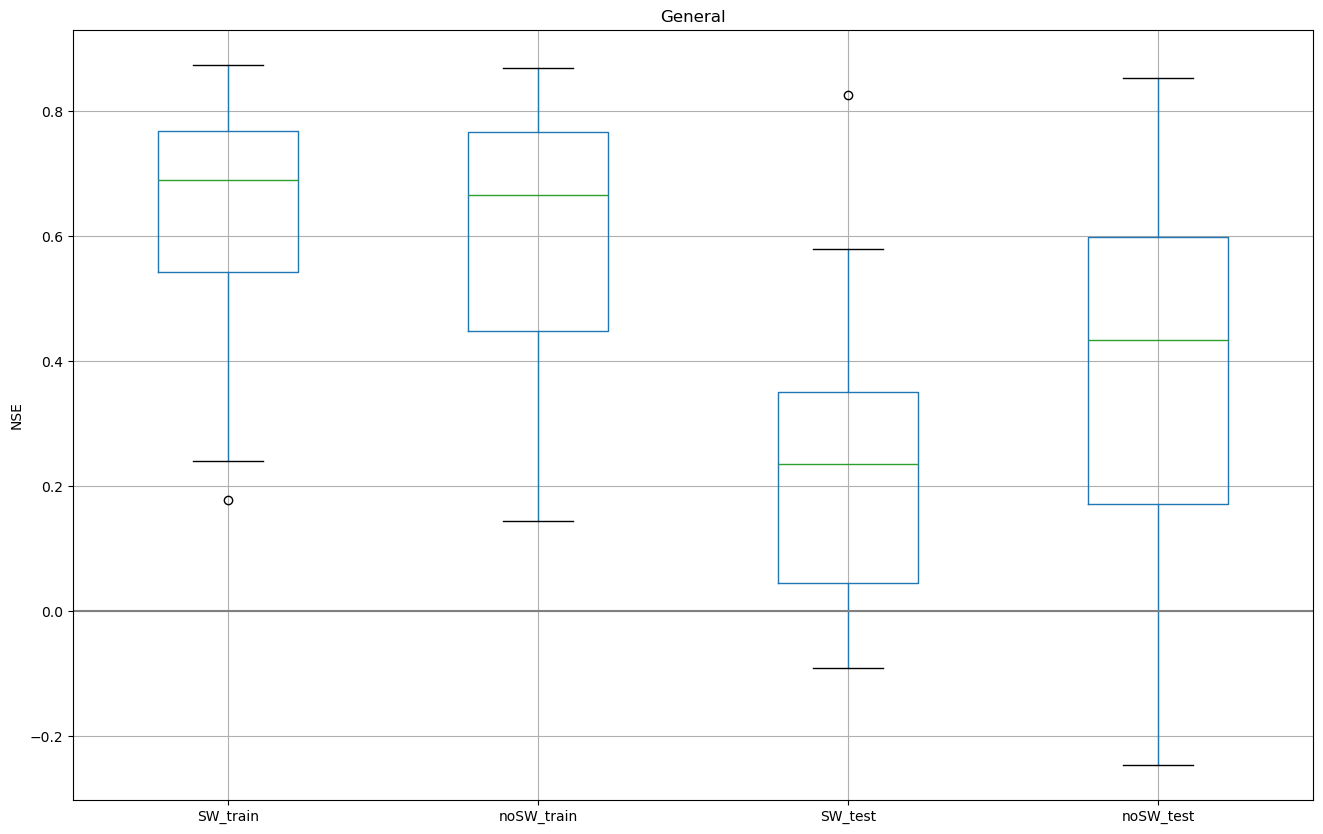

In [7]:
fig, axs = plt.subplots(1, 1, figsize=(16, 10),sharey=True)
nse_df = comp_plots.boxplot_from_tuple(results_tuple,ax=axs,tuple_names=default_order,exp_name = 'General')
# axs[0].set_ylim([-1.5,1])

In [7]:
nse_df

,1159302,1834101,3103450,4148535,4150600,4150680,4150700,4152450,5101500,5608096
SW_train,0.873711,0.776627,0.240646,0.508891,0.715183,0.742266,0.664193,0.176951,0.640623,0.812263
noSW_train,0.868448,0.816687,0.189805,0.405077,0.703205,0.699496,0.631866,0.143198,0.580260,0.786786
SW_test,0.243483,0.826298,0.004777,0.144514,0.011642,0.579353,0.225531,-0.091500,0.365059,0.304340
noSW_test,0.500010,0.853213,-0.246800,0.128896,0.295654,0.614904,0.573969,0.034191,0.607376,0.366436


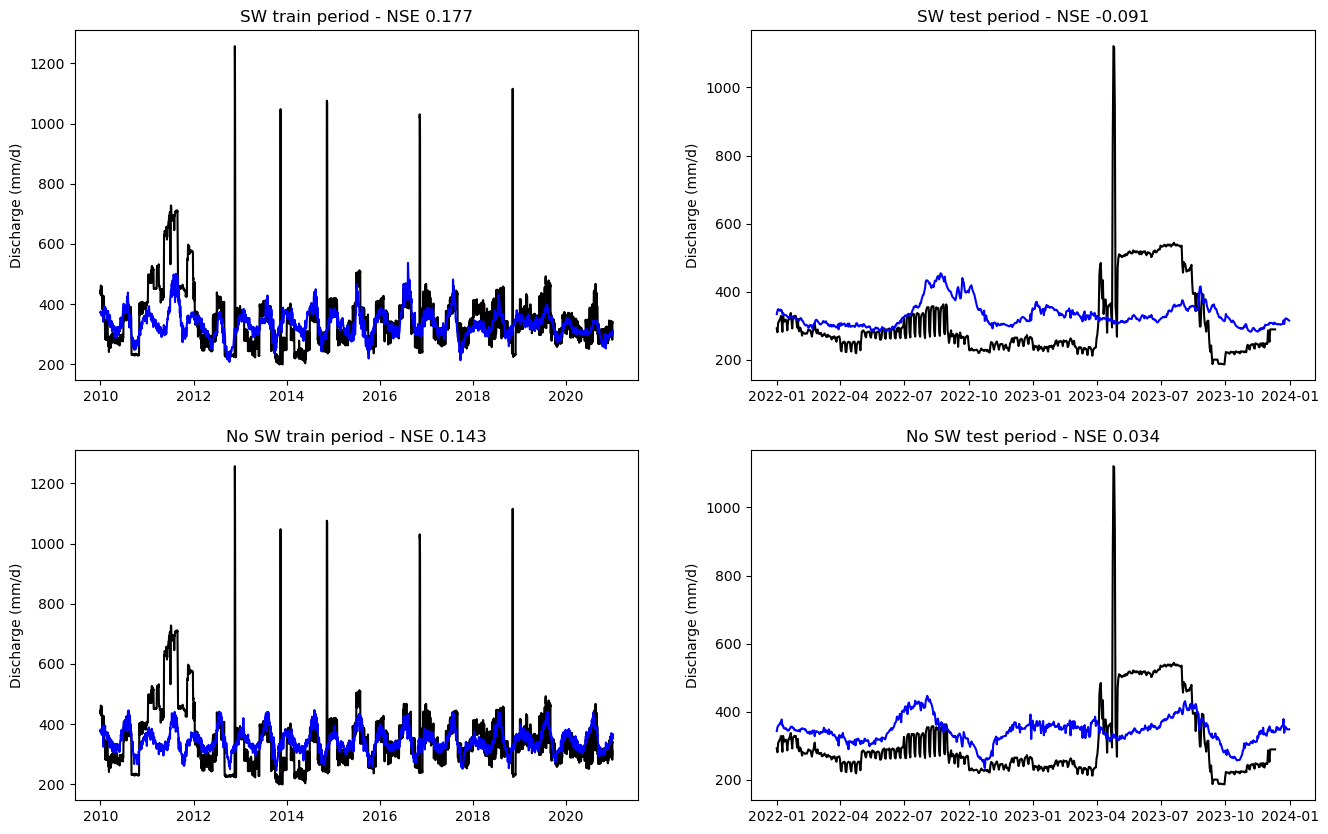

In [9]:
eval_wrapper.quick_basin_plot(*results_tuple, basin_key = '4152450');

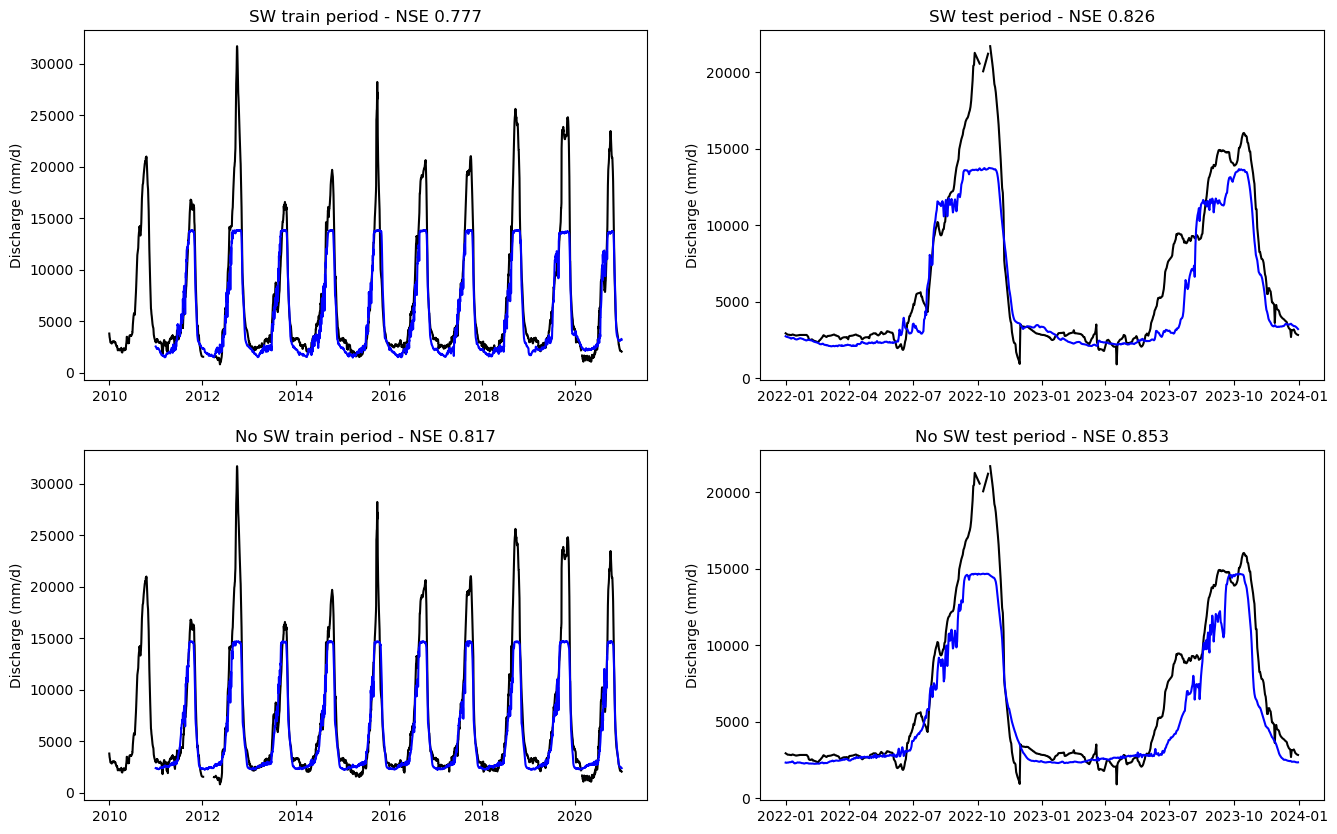

In [10]:
eval_wrapper.quick_basin_plot(*results_tuple, basin_key = '1834101');

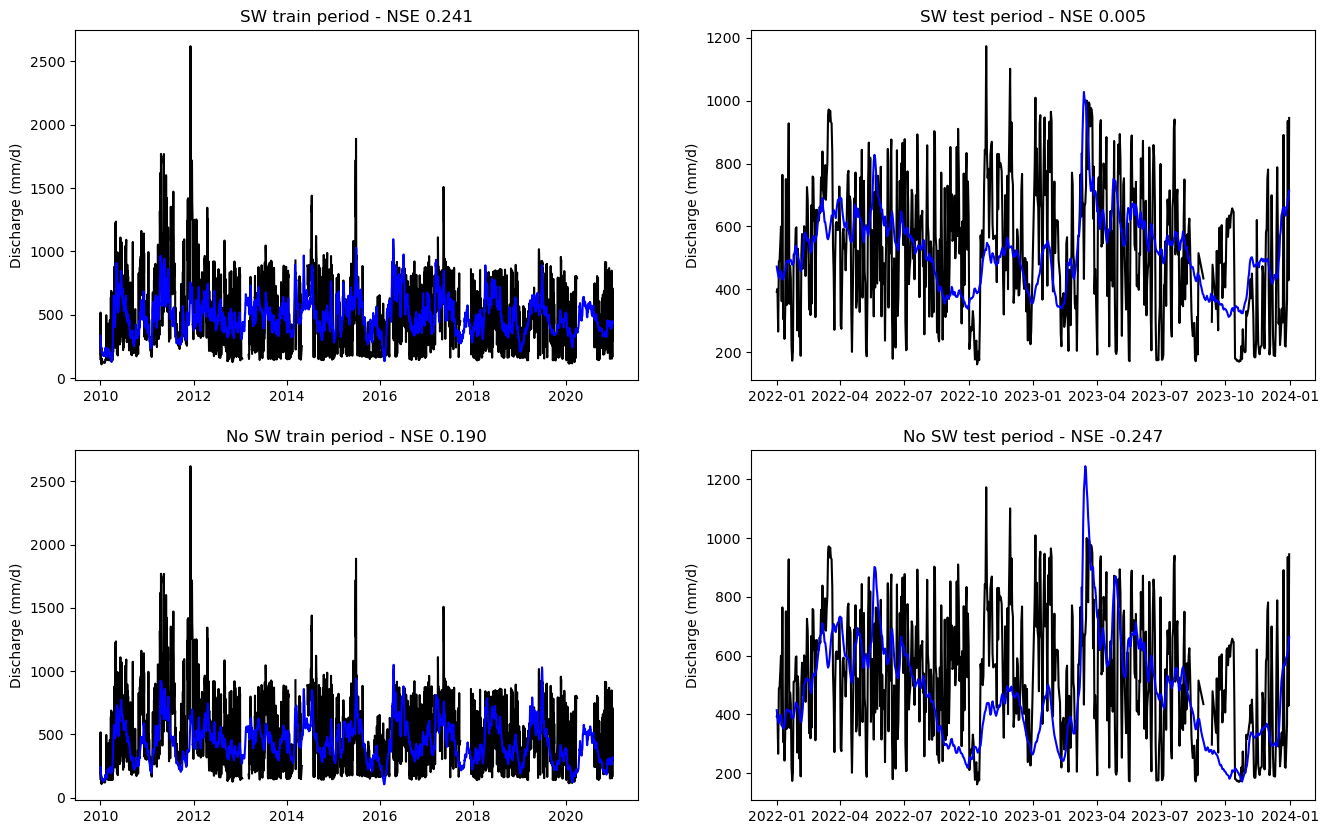

In [11]:
eval_wrapper.quick_basin_plot(*results_tuple, basin_key = '3103450');

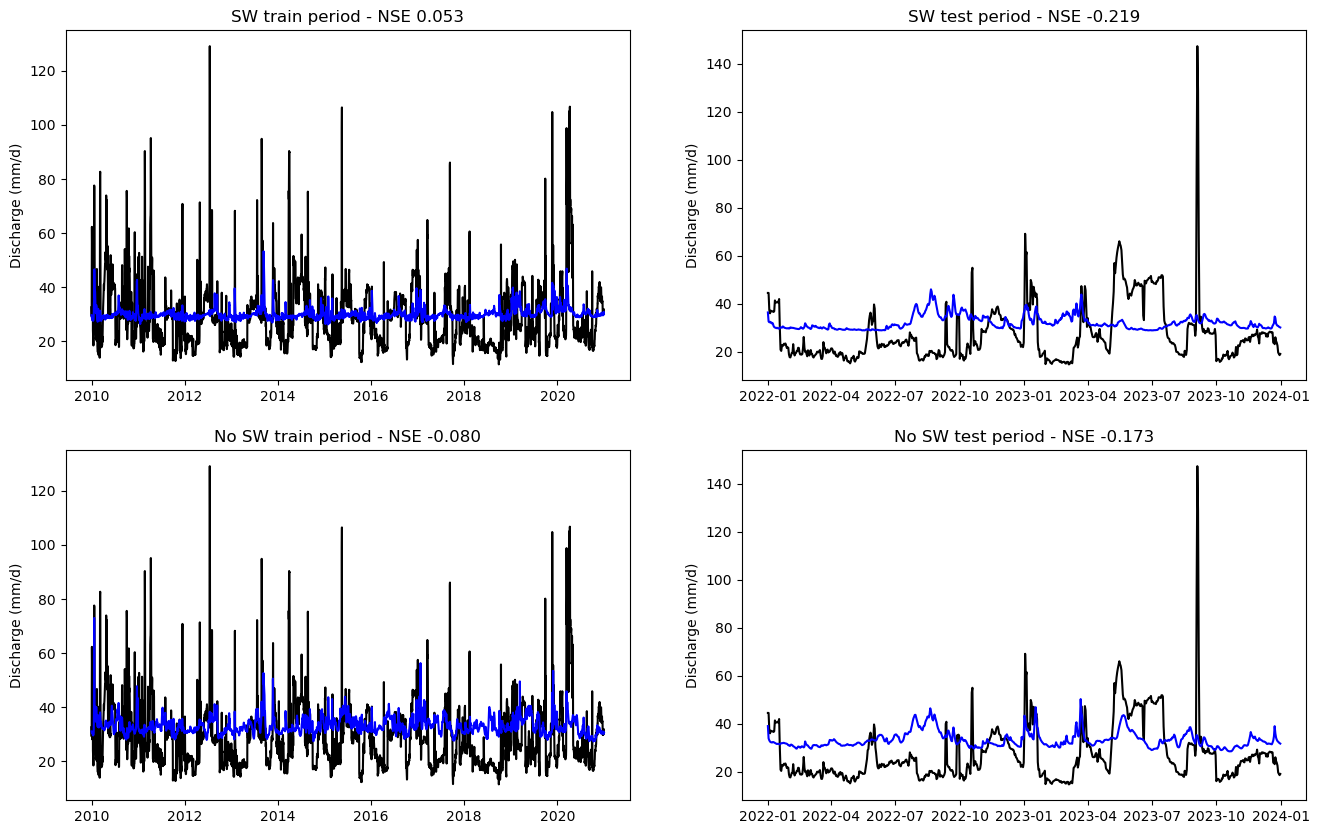

In [8]:
eval_wrapper.quick_basin_plot(*results_tuple, basin_key = '4152050');

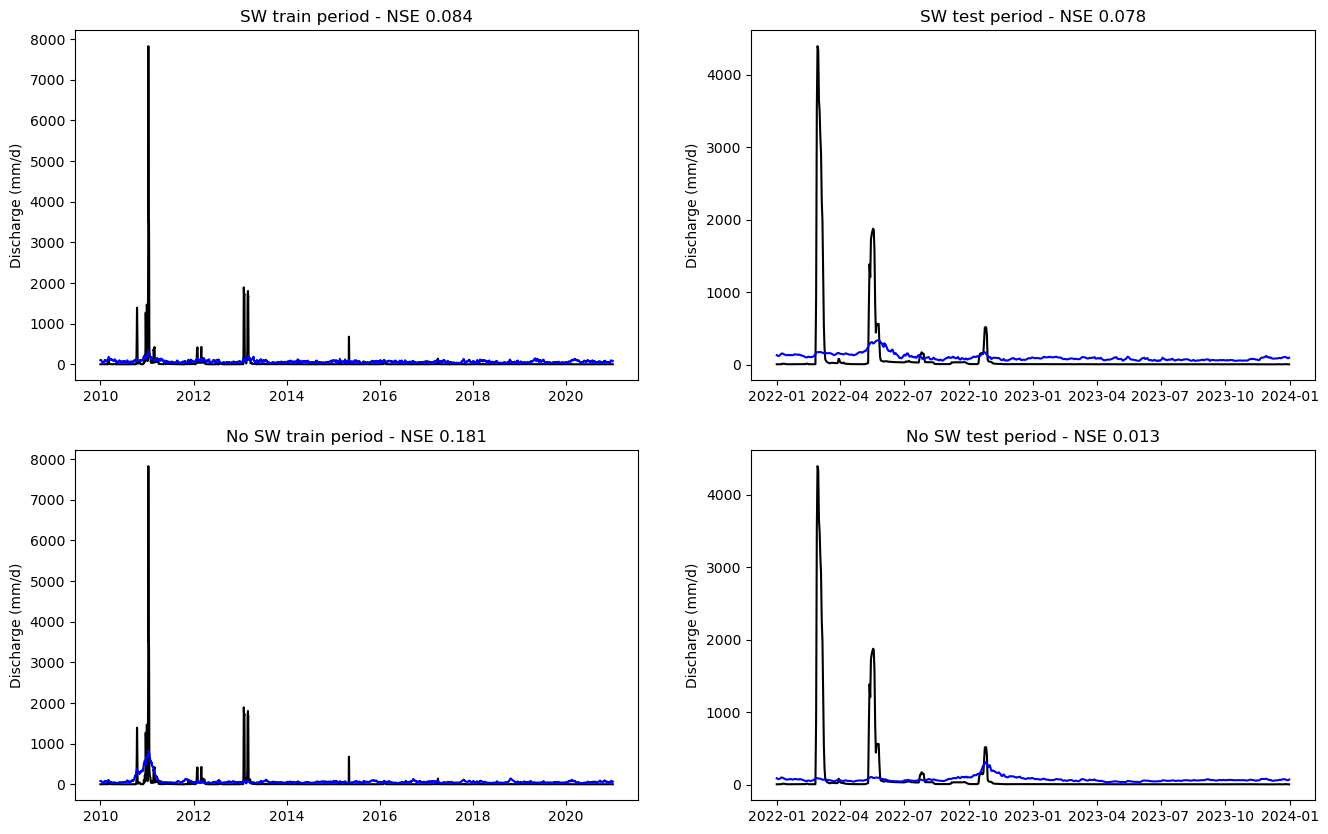

In [9]:
eval_wrapper.quick_basin_plot(*results_tuple, basin_key = '5101500');

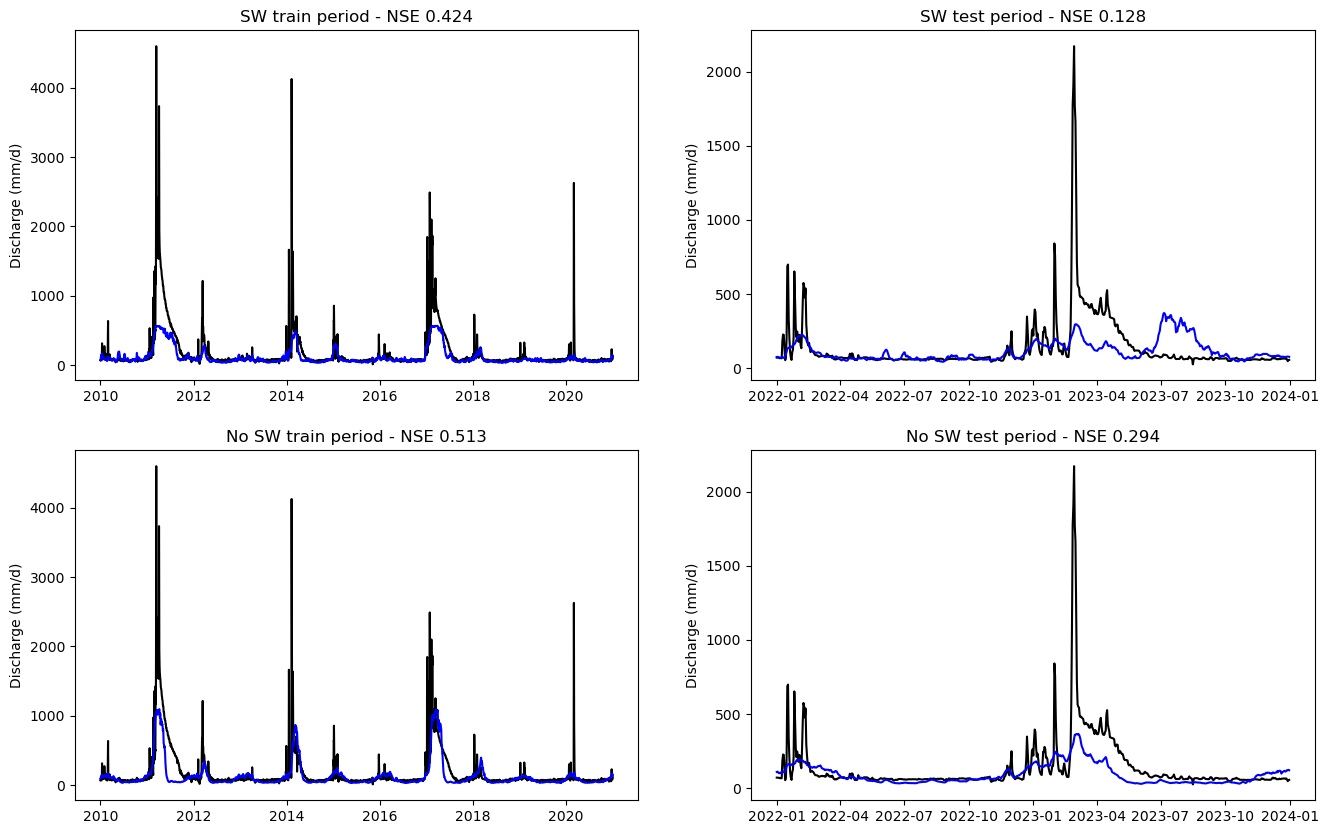

In [10]:
eval_wrapper.quick_basin_plot(*results_tuple, basin_key = '5608096');